In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
paneldf = pd.read_parquet('data/panel.parquet', engine='pyarrow')
paneldf.head()

,date,ticker,ret,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,excess_ret
0,2010-02-01,A,0.115441,0.0339,0.0149,0.0318,-0.0029,0.0142,0.0,0.0369,0.115441
1,2010-02-01,AAPL,0.063347,0.0339,0.0149,0.0318,-0.0029,0.0142,0.0,0.0369,0.063347
2,2010-02-01,ABT,0.032274,0.0339,0.0149,0.0318,-0.0029,0.0142,0.0,0.0369,0.032274
3,2010-02-01,ACGL,0.033538,0.0339,0.0149,0.0318,-0.0029,0.0142,0.0,0.0369,0.033538
4,2010-02-01,ACN,-0.025199,0.0339,0.0149,0.0318,-0.0029,0.0142,0.0,0.0369,-0.025199


In [6]:
paneldf.shape

(84348, 11)

### Basic Statistical Summary Table

In [45]:
paneldf.describe()

,date,ret,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,excess_ret
count,84348,84348.000000,84348.000000,84348.000000,84348.000000,84348.000000,84348.000000,84348.000000,84348.000000,84348.000000
mean,2017-09-12 19:40:38.412292,0.011371,0.011074,-0.000826,-0.001393,0.002991,0.000172,0.000988,0.002689,0.010383
min,2010-02-01 00:00:00,-1.785360,-0.133500,-0.081800,-0.138300,-0.047800,-0.070800,0.000000,-0.161700,-1.786560
25%,2014-01-01 00:00:00,-0.033505,-0.015400,-0.019300,-0.019200,-0.011000,-0.014300,0.000000,-0.017000,-0.034512
50%,2017-11-01 00:00:00,0.014144,0.014200,-0.000300,-0.003900,0.003200,-0.000800,0.000100,0.004500,0.013299
75%,2021-06-01 00:00:00,0.058199,0.035500,0.015400,0.014800,0.013300,0.012400,0.001600,0.025600,0.057283
max,2024-12-01 00:00:00,1.774603,0.135800,0.083400,0.128600,0.071900,0.077300,0.004800,0.099700,1.773003
std,NaN,0.085657,0.043667,0.027521,0.033169,0.019562,0.020958,0.001458,0.035723,0.085697


### Check for any null values column-wise

In [4]:
paneldf.isna().sum()

date          0
ticker        0
ret           0
Mkt-RF        0
SMB           0
HML           0
RMW           0
CMA           0
RF            0
Mom           0
excess_ret    0
dtype: int64

### Checking for duplicates

In [9]:
duplicates = paneldf.duplicated(subset=['date', 'ticker'])
print(paneldf[duplicates])

Empty DataFrame
Columns: [date, ticker, ret, Mkt-RF, SMB, HML, RMW, CMA, RF, Mom, excess_ret]
Index: []


In [51]:
factors = pd.read_csv("data/factors.csv")

### Distribution of Excess Returns

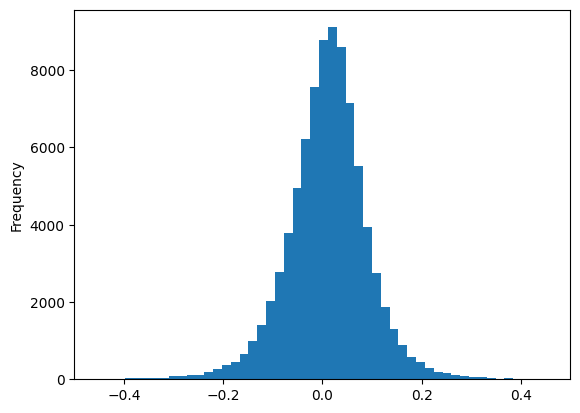

In [53]:
paneldf['excess_ret'].plot(kind ='hist', bins=200, xlim=(-0.5, 0.5))
plt.show()

In [50]:
print(f"Skewness: {paneldf['excess_ret'].skew():.4f}")
print(f"Kurtosis: {paneldf['excess_ret'].kurt():.4f}")

Skewness: -0.5187
Kurtosis: 14.2445


From above, the negative skewness confirms what the histogram shows us, that is,  the 'Excess Returns' is slightly left skewed and has an excess positive kurtosis. This is called leptokurtosis (excess kurtosis), and it's more significant than the slight skew. It means extreme returns happen more often than a normal distribution would predict.

### Market Excess Return vs. Time

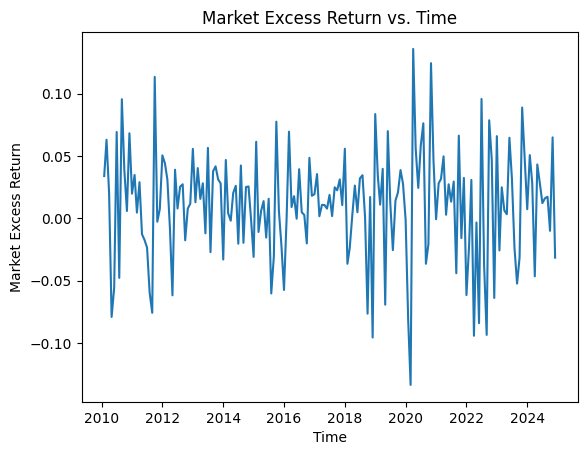

In [57]:
plt.plot(paneldf['date'], paneldf['Mkt-RF'])
plt.xlabel("Time")
plt.ylabel("Market Excess Return")
plt.title('Market Excess Return vs. Time')
plt.show()

Volatility: As expected, we notice the swings get larger around 2010-11 (European Debt crisis) and 2020(COVID). Calm periods and turbulent periods are tend to cluster together.
Also, we see Market Excess Return  fluctuates around zero, as expected. This is because it's an excess return and not price. 

### Size Premium vs Time

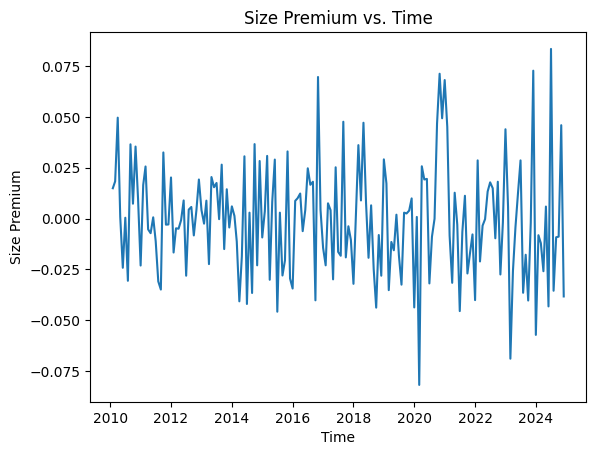

In [39]:
plt.plot(paneldf['date'], paneldf['SMB'])
plt.xlabel("Time")
plt.ylabel("Size Premium")
plt.title('Size Premium vs. Time')
plt.show()

Similar to excess returns, SMB(Small minus Big/ Size Premium) also reflects the big financial events. It also relfects the recovery that small caps had after 2020.

### Value Premium vs. Time

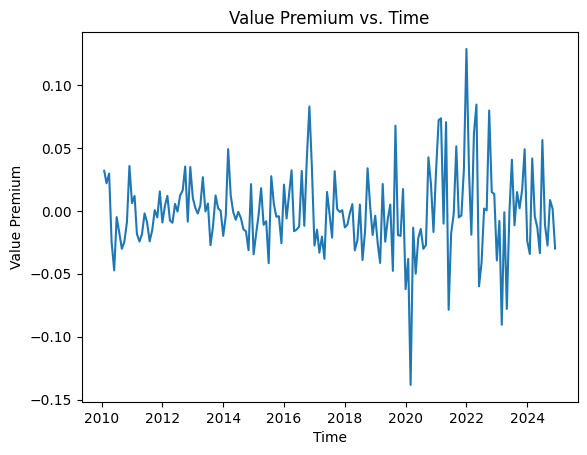

In [38]:
plt.plot(paneldf['date'], paneldf['HML'])
plt.xlabel("Time")
plt.ylabel("Value Premium")
plt.title('Value Premium vs. Time')
plt.show()

### Momentum vs. Time

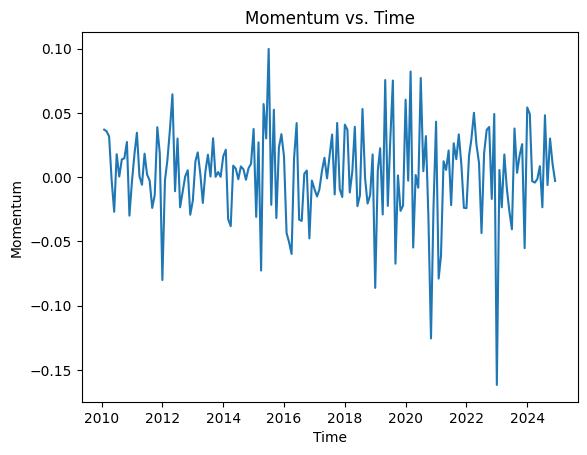

In [32]:
plt.plot(paneldf['date'], paneldf['Mom'])
plt.xlabel("Time")
plt.ylabel("Momentum")
plt.title('Momentum vs. Time')
plt.show()

Momentum tends to sharply reverse during market recoveries (like 2009, 2020) because recent losers suddenly outperform.

### Profitability premium vs. Time

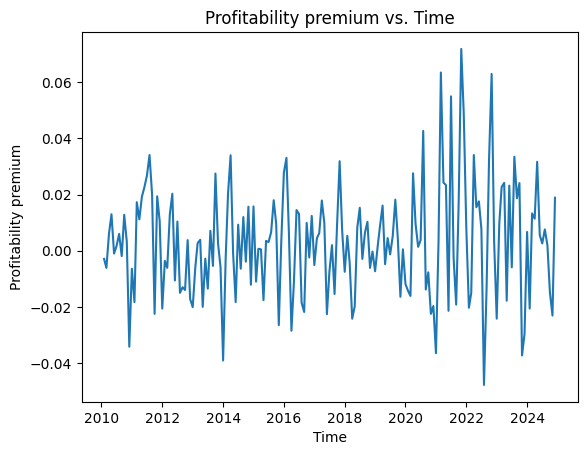

In [59]:
plt.plot(paneldf['date'], paneldf['RMW'])
plt.xlabel("Time")
plt.ylabel("Profitability premium")
plt.title('Profitability premium vs. Time')
plt.show()

### Investment premium vs Time

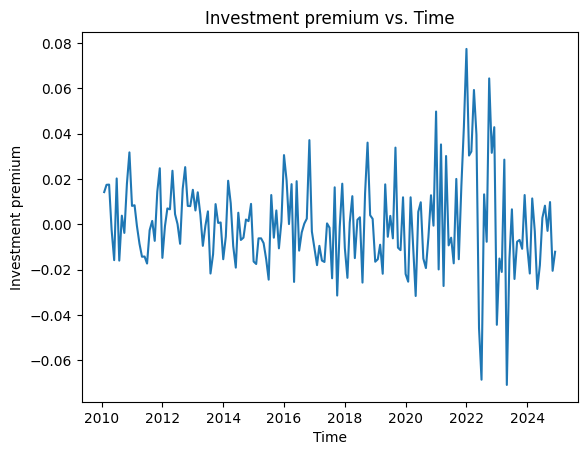

In [36]:
plt.plot(paneldf['date'], paneldf['CMA'])
plt.xlabel("Time")
plt.ylabel("Investment premium")
plt.title('Investment premium vs. Time')
plt.show()

### Correlation Matrix

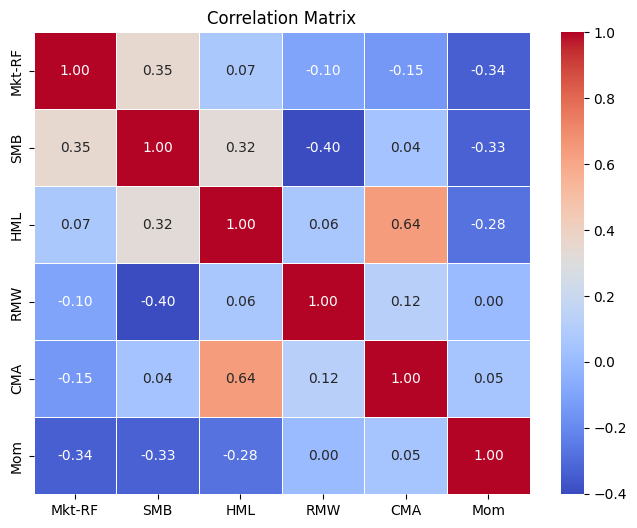

In [7]:
df = paneldf[['Mkt-RF','SMB','HML', 'RMW','CMA', 'Mom']]
corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.savefig("outputs/figures/corr_matrix.png", dpi=150)
plt.show()


The correlation matrix reveals that the six factors are largely uncorrelated by construction, supporting their use as independent predictors. The most notable exception is HML and CMA (r = 0.64), which reflects the well-documented overlap between value and conservative investment strategies. This pair will be examined more closely later.